In [10]:
# کد مدل YOLO
import os
import random

# مسیر فولدرهای اصلی
folders = [
    r"C:\Users\HP\Desktop\Saina_Test_Train\Saina_Test_Train\bottle",
    r"C:\Users\HP\Desktop\Saina_Test_Train\Saina_Test_Train\dry",
    r"C:\Users\HP\Desktop\Saina_Test_Train\Saina_Test_Train\wet"
]

# شمارش تعداد عکس‌ها در هر کلاس
class_counts = {}
for folder in folders:
    images_dir = os.path.join(folder, "images")
    count = len([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_name = os.path.basename(folder)
    class_counts[class_name] = count

print("تعداد عکس‌های اولیه در هر کلاس:")
for cls, cnt in class_counts.items():
    print(f" - {cls}: {cnt}")

#متعادل سازی سه گروه
target_size = min(class_counts.values())
print(f"\n بعد از متعادل سازی : {target_size} عکس")

# تقسیم 70/15/15
n_train = int(0.7 * target_size)
n_val = int(0.15 * target_size)
n_test = target_size - n_train - n_val

print("\n تعداد عکس‌ها در هر بخش برای هر کلاس:")
print(f" - Train: {n_train}")
print(f" - Val:   {n_val}")
print(f" - Test:  {n_test}")

""" تعداد عکس‌های اولیه در هر کلاس:
 - bottle: 181
 - dry: 231
 - wet: 130

 بعد از متعادل‌سازی: 130 عکس

 تعداد عکس‌ها در هر بخش برای هر کلاس:
 - Train: 91
 - Val:   19
 - Test:  20"""

تعداد عکس‌های اولیه در هر کلاس:
 - bottle: 459
 - dry: 399
 - wet: 395

 بعد از متعادل سازی : 395 عکس

 تعداد عکس‌ها در هر بخش برای هر کلاس:
 - Train: 276
 - Val:   59
 - Test:  60


' تعداد عکس\u200cهای اولیه در هر کلاس:\n - bottle: 181\n - dry: 231\n - wet: 130\n\n بعد از متعادل\u200cسازی: 130 عکس\n\n تعداد عکس\u200cها در هر بخش برای هر کلاس:\n - Train: 91\n - Val:   19\n - Test:  20'

In [11]:
import os
import shutil
import random

# مسیر دیتاست اصلی
base_path = r"C:\Users\HP\Desktop\Saina_Test_Train\Saina_Test_Train"

# مسیر خروجی ساختار جدید
output_path = r"C:\Users\HP\Desktop\Saina_Test_Train\YOLO_Split"

# نسبت تقسیم داده‌ها
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

# ساخت پوشه‌های خروجی
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_path, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(output_path, split, "labels"), exist_ok=True)

# گرفتن همه تصاویر از کلاس‌ها
all_images = []
for cls in ["bottle", "dry", "wet"]:
    img_dir = os.path.join(base_path, cls, "images")
    lbl_dir = os.path.join(base_path, cls, "labels")
    for img_file in os.listdir(img_dir):
        if img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            label_file = os.path.splitext(img_file)[0] + ".txt"
            all_images.append((os.path.join(img_dir, img_file),
                               os.path.join(lbl_dir, label_file)))

# شافل کردن داده‌ها
random.shuffle(all_images)

# تقسیم به train/val/test
n_total = len(all_images)
n_train = int(train_ratio * n_total)
n_val = int(val_ratio * n_total)

train_set = all_images[:n_train]
val_set = all_images[n_train:n_train+n_val]
test_set = all_images[n_train+n_val:]

# تابع کپی
def copy_files(dataset, split):
    for img_path, lbl_path in dataset:
        shutil.copy(img_path, os.path.join(output_path, split, "images"))
        if os.path.exists(lbl_path):
            shutil.copy(lbl_path, os.path.join(output_path, split, "labels"))

copy_files(train_set, "train")
copy_files(val_set, "val")
copy_files(test_set, "test")

print(f"Done! Train={len(train_set)}, Val={len(val_set)}, Test={len(test_set)}")


Done! Train=877, Val=250, Test=126


In [ ]:
import os
import shutil
import random

# مسیر فولدرهای اصلی
folders = [
    r"C:\Users\Asus\Desktop\AI-Course\Saina_Test_Train\bottle",
    r"C:\Users\Asus\Desktop\AI-Course\Saina_Test_Train\dry",
    r"C:\Users\Asus\Desktop\AI-Course\Saina_Test_Train\wet"
]

# مسیر خروجی دیتاست نهایی
output_base = r"C:\Users\Asus\Desktop\AI-Course\Saina_YOLO_Dataset"

splits = ["train", "val", "test"]

def make_dirs():
    for split in splits:
        os.makedirs(os.path.join(output_base, "images", split), exist_ok=True)
        os.makedirs(os.path.join(output_base, "labels", split), exist_ok=True)

def balance_and_split_dataset(base_folder, target_size):
    images_dir = os.path.join(base_folder, "images")
    labels_dir = os.path.join(base_folder, "labels")

    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(image_files)

    # undersampling: فقط target_size عکس نگه می‌داریم
    image_files = image_files[:target_size]

    n = len(image_files)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    n_test = n - n_train - n_val

    train_files = image_files[:n_train]
    val_files = image_files[n_train:n_train+n_val]
    test_files = image_files[n_train+n_val:]

    def copy_files(file_list, split):
        for img in file_list:
            name, _ = os.path.splitext(img)
            label = name + ".txt"

            src_img = os.path.join(images_dir, img)
            src_lbl = os.path.join(labels_dir, label)

            dst_img = os.path.join(output_base, "images", split, img)
            dst_lbl = os.path.join(output_base, "labels", split, label)

            shutil.copy(src_img, dst_img)
            if os.path.exists(src_lbl):
                shutil.copy(src_lbl, dst_lbl)

    copy_files(train_files, "train")
    copy_files(val_files, "val")
    copy_files(test_files, "test")

# اجرای کل فرآیند
make_dirs()

# اول تعداد عکس‌های هر کلاس رو پیدا می‌کنیم
class_counts = []
for folder in folders:
    images_dir = os.path.join(folder, "images")
    count = len([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts.append(count)

# کمترین تعداد عکس بین کلاس‌ها
target_size = min(class_counts)

# تقسیم متعادل
for folder in folders:
    balance_and_split_dataset(folder, target_size)

print(" دیتاست به صورت متعادل (همه کلاس‌ها برابر) و به نسبت 70/15/15 تقسیم شد.")

In [ ]:
from ultralytics import YOLO

# بارگذاری مدل پایه
model = YOLO("yolov8s.pt")   # نسخه کوچک و سریع

# آموزش مدل روی دیتاست آماده
results = model.train(
    data = r"C:\Users\Asus\Desktop\AI-Course\Saina_Test_Train\Saina_YOLO_Project\data.yaml",  # مسیر فایل yaml دیتاست
    epochs=100,             # تعداد epoch 
    imgsz=640,              # سایز ورودی تصویر
    batch=16,              
    workers=4,              # تعداد پردازشگر برای بارگذاری داده
    patience=10,            
    device="cpu",               # در اخر با GPU مدل اموزش داده شد
    optimizer="Adam",       
    lr0=0.001,              # نرخ یادگیری اولیه
    weight_decay=0.0005,    # برای جلوگیری از overfitting
    project="Saina_YOLO_Project",  # مسیر ذخیره نتایج
    name="exp1"             
)

# بهترین وزن‌ها به صورت خودکار ذخیره می‌شن در:
# مدل ذخیره شده :r"C:\Users\HP\Desktop\best.pt"

تست گرفتن از مدل YOLO


image 1/1 C:\Users\HP\Desktop\trashnet_split\test\plastic\plastic80.jpg: 480x640 1 bottle, 124.7ms
Speed: 2.6ms preprocess, 124.7ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


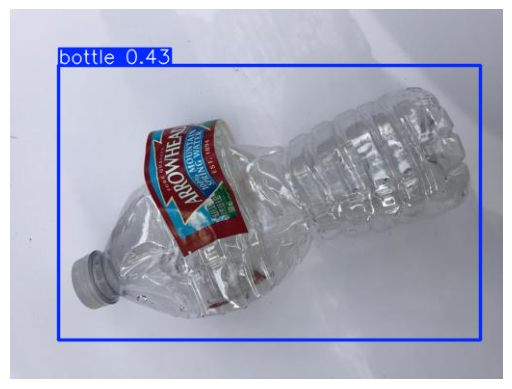

Detected: bottle with confidence 0.43


In [7]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
# تست روی یک تصویر
# بارگذاری مدل
model = YOLO(r"C:\Users\HP\Desktop\best.pt")

results = model.predict(
    source=r"C:\Users\HP\Desktop\trashnet_split\test\plastic\plastic80.jpg",
    save=False
)

img = results[0].plot()  # تصویر با bounding box
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# چاپ نتایج تشخیص
for r in results:
    for box in r.boxes:
        cls_id = int(box.cls[0])          # شماره کلاس
        conf = float(box.conf[0])         # میزان اعتماد
        label = model.names[cls_id]       # نام کلاس
        print(f"Detected: {label} with confidence {conf:.2f}")



image 1/1 C:\Users\HP\Desktop\YOLO_TEST\paper72.jpg: 480x640 1 dry, 130.8ms
Speed: 2.8ms preprocess, 130.8ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
paper72.jpg -> Detected: dry with confidence 0.90

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\trash95.jpg: 480x640 1 wet, 117.8ms
Speed: 2.6ms preprocess, 117.8ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
trash95.jpg -> Detected: wet with confidence 0.52

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\glass478.jpg: 480x640 1 bottle, 117.9ms
Speed: 2.2ms preprocess, 117.9ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
glass478.jpg -> Detected: bottle with confidence 0.85

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\paper156.jpg: 480x640 1 dry, 111.4ms
Speed: 2.9ms preprocess, 111.4ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
paper156.jpg -> Detected: dry with confidence 0.93

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\cardboard1.jpg: 480x640 1 dry, 115.4ms
Speed: 1.7

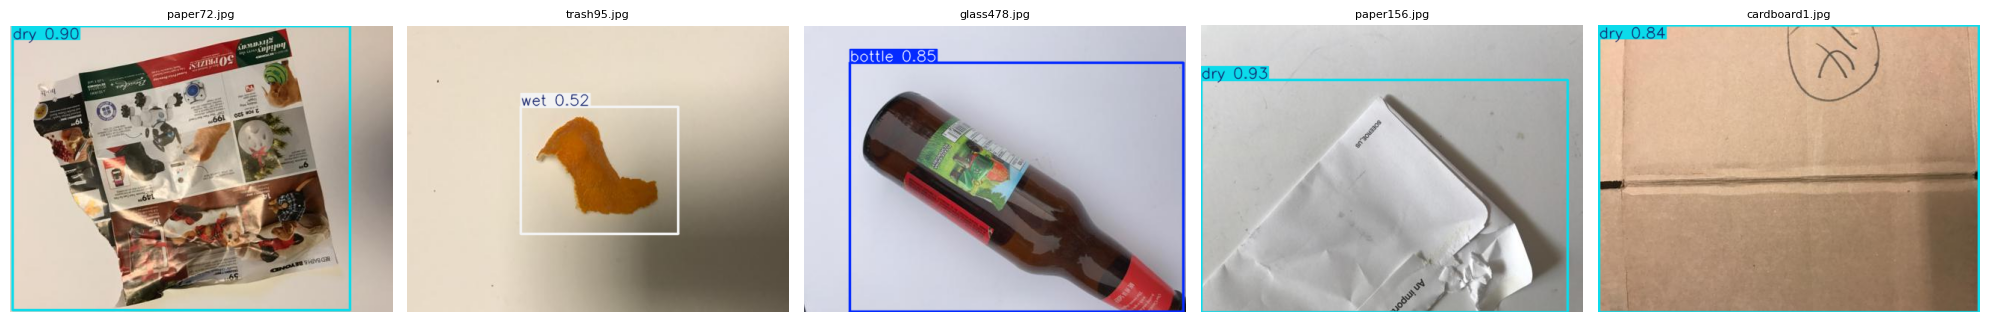

In [11]:
import os
import random
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# بارگذاری مدل
model = YOLO(r"C:\Users\HP\Desktop\best.pt")

# مسیر پوشه تصاویر
folder_path = r"C:\Users\HP\Desktop\YOLO_TEST"

# گرفتن لیست همه فایل‌ها در پوشه
all_images = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# انتخاب 5 تصویر رندوم
sample_images = random.sample(all_images, 5)

# آماده‌سازی شکل با 5 ساب‌پلات در یک ردیف
fig, axes = plt.subplots(1, 5, figsize=(20, 5))  # 1 ردیف، 5 ستون

for ax, img_path in zip(axes, sample_images):
    results = model.predict(source=img_path, save=False)

    # گرفتن تصویر با جعبه‌ها
    img = results[0].plot()
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # نمایش در subplot
    ax.imshow(img_rgb)
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis("off")

    # چاپ نتایج تشخیص در کنسول
    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            label = model.names[cls_id]
            print(f"{os.path.basename(img_path)} -> Detected: {label} with confidence {conf:.2f}")

plt.tight_layout()
plt.show()


مدل TrashNet

In [ ]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

root_dir = r"C:\Users\HP\Desktop\trashnet_split"
train_dir = r"C:\Users\HP\Desktop\trashnet_split\train"
val_dir   = r"C:\Users\HP\Desktop\trashnet_split\val"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 30           
LR         = 1e-4         

MODEL_PATH = r"C:\Users\HP\Desktop\trashnet_best_model.pth"

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])   
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

class_names = train_dataset.classes
print(f"Detected classes: {class_names}")
# Expected output: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 6)     
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

best_acc = 0.0
print("Training started...\n")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_acc = 100. * train_correct / train_total


    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * val_correct / val_total

    
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} Acc: {train_acc:6.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} Acc: {val_acc:6.2f}%")

 
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_accuracy': val_acc,
            'class_names': class_names
        }, MODEL_PATH)
        print(f"Best model saved! Val accuracy: {val_acc:.2f}%\n")

print(f"\nTraining finished!")
print(f"Best validation accuracy: {best_acc:.2f}%")
print(f"Model saved at: {MODEL_PATH}")
"""Using device: cpu
Detected classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Training started...

Epoch  1/30 | Train Loss: 0.8633 Acc:  70.03% | Val Loss: 0.5622 Acc:  81.68%
Best model saved! Val accuracy: 81.68%

Epoch  2/30 | Train Loss: 0.3780 Acc:  87.85% | Val Loss: 0.5324 Acc:  82.72%
Best model saved! Val accuracy: 82.72%

Epoch  3/30 | Train Loss: 0.2746 Acc:  92.57% | Val Loss: 0.4427 Acc:  85.34%
Best model saved! Val accuracy: 85.34%

Epoch  4/30 | Train Loss: 0.1632 Acc:  94.84% | Val Loss: 0.4518 Acc:  85.34%
Epoch  5/30 | Train Loss: 0.1244 Acc:  97.50% | Val Loss: 0.4366 Acc:  87.96%
Best model saved! Val accuracy: 87.96%

Epoch  6/30 | Train Loss: 0.1410 Acc:  96.08% | Val Loss: 0.3891 Acc:  89.01%
Best model saved! Val accuracy: 89.01%

Epoch  7/30 | Train Loss: 0.0973 Acc:  97.45% | Val Loss: 0.4312 Acc:  87.43%
Epoch  8/30 | Train Loss: 0.0795 Acc:  97.96% | Val Loss: 0.4074 Acc:  88.48%
Epoch  9/30 | Train Loss: 0.1187 Acc:  98.30% | Val Loss: 0.4832 Acc:  87.96%
Epoch 10/30 | Train Loss: 0.0957 Acc:  97.56% | Val Loss: 0.4205 Acc:  87.17%
Epoch 11/30 | Train Loss: 0.0516 Acc:  98.92% | Val Loss: 0.4329 Acc:  87.70%
...

Training finished!
Best validation accuracy: 89.01%
Model saved at: C:\Users\HP\Desktop\trashnet_best_model.pth
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings..."""

MODEL_PATH = r"C:\Users\HP\Desktop\trashnet_best_model.pth"
TEST_DIR = r"C:\Users\HP\Desktop\trashnet_split\test"  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_dataset = datasets.ImageFolder(TEST_DIR, transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

checkpoint = torch.load(MODEL_PATH)
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 6)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

acc = 100 * correct / total
print(f"\n acc test: {acc:.2f}%")
print(f"true: {correct} in {total}")


#درصد دقت و خطا روی دیتاست تست TrashNet
"""acc test: 85.12%
true: 326 in 383"""


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:   
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_dataset.classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Test Dataset")
plt.show()
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

#معیارهای ارزیابی و ماتریس درهم ریختگی
"""              precision    recall  f1-score   support

   cardboard       0.93      0.87      0.90        61
       glass       0.86      0.75      0.80        76
       metal       0.76      0.92      0.83        62
       paper       0.89      0.89      0.89        90
     plastic       0.82      0.88      0.85        73
       trash       0.88      0.71      0.79        21

    accuracy                           0.85       383
   macro avg       0.86      0.84      0.84       383
weighted avg       0.86      0.85      0.85       383

Confusion Matrix:
 [[53  0  2  5  1  0]
 [ 0 57 12  0  7  0]
 [ 0  2 57  0  3  0]
 [ 4  0  2 80  3  1]
 [ 0  7  0  1 64  1]
 [ 0  0  2  4  0 15]]"""

تست تصویری از CNN

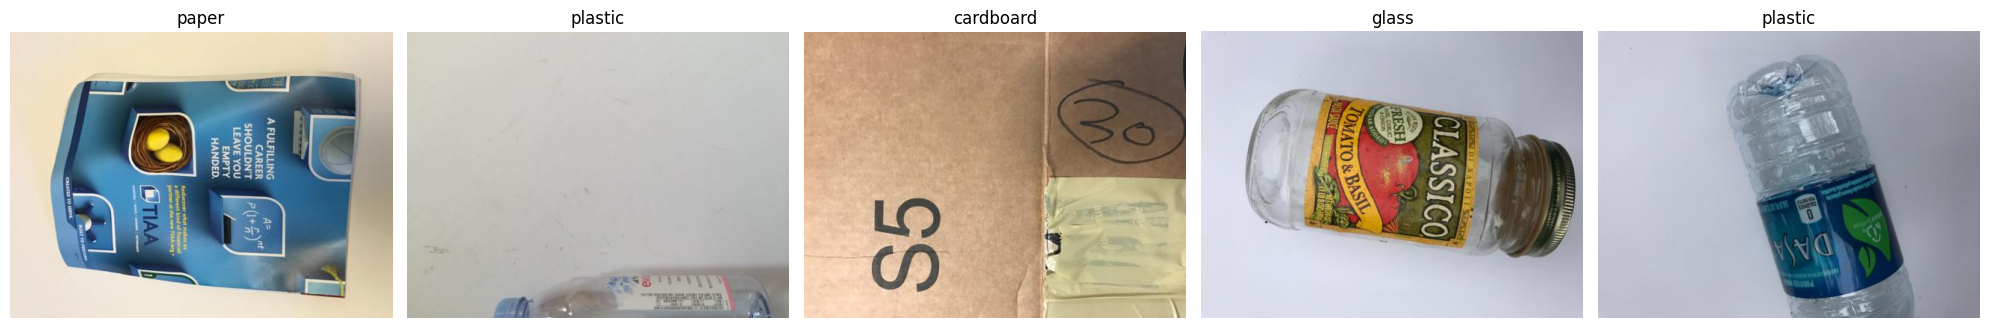

In [33]:
import os
import random
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# مسیر فایل مدل ذخیره‌شده
MODEL_PATH = r"C:\Users\HP\Desktop\trashnet_best_model.pth"

# بارگذاری checkpoint
checkpoint = torch.load(MODEL_PATH, map_location="cpu")

# تعریف معماری دقیق همون چیزی که موقع آموزش استفاده کردی (اینجا ResNet18 برای TrashNet)
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 6)  # چون TrashNet شش کلاس داره

# بارگذاری وزن‌ها
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# کلاس‌ها
class_names = checkpoint.get('class_names', ["cardboard", "glass", "metal", "paper", "plastic", "trash"])

# پیش‌پردازش تصاویر
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# مسیر پوشه‌ی تست (شامل ۶ پوشه کلاس)
test_dir = r"C:\Users\HP\Desktop\trashnet_split\test"

# جمع‌آوری همه‌ی مسیرهای تصاویر از زیرپوشه‌ها
all_images = []
for cls in os.listdir(test_dir):
    cls_folder = os.path.join(test_dir, cls)
    if os.path.isdir(cls_folder):
        for img_file in os.listdir(cls_folder):
            all_images.append(os.path.join(cls_folder, img_file))

# انتخاب 5 تصویر رندوم
image_files = random.sample(all_images, 5)

# نمایش 5 تصویر افقی
plt.figure(figsize=(20, 5))
for i, img_path in enumerate(image_files):
    img = Image.open(img_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)
        label = class_names[predicted.item()]

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()


تست گرفتن مدل YOLO و معیارهای ارزیابی


image 1/50 C:\Users\HP\Desktop\YOLO_TEST\images\biological580.jpg: 640x640 1 wet, 157.8ms
image 2/50 C:\Users\HP\Desktop\YOLO_TEST\images\biological587.jpg: 448x640 3 wets, 115.0ms
image 3/50 C:\Users\HP\Desktop\YOLO_TEST\images\biological74.jpg: 640x640 1 wet, 150.6ms
image 4/50 C:\Users\HP\Desktop\YOLO_TEST\images\biological797.jpg: 640x640 1 wet, 148.4ms
image 5/50 C:\Users\HP\Desktop\YOLO_TEST\images\biological964.jpg: 480x640 1 wet, 117.1ms
image 6/50 C:\Users\HP\Desktop\YOLO_TEST\images\cardboard1.jpg: 480x640 1 dry, 113.2ms
image 7/50 C:\Users\HP\Desktop\YOLO_TEST\images\cardboard107.jpg: 480x640 1 dry, 109.5ms
image 8/50 C:\Users\HP\Desktop\YOLO_TEST\images\cardboard134.jpg: 480x640 1 dry, 111.3ms
image 9/50 C:\Users\HP\Desktop\YOLO_TEST\images\cardboard149.jpg: 480x640 1 bottle, 1 dry, 127.6ms
image 10/50 C:\Users\HP\Desktop\YOLO_TEST\images\cardboard175.jpg: 480x640 1 dry, 114.5ms
image 11/50 C:\Users\HP\Desktop\YOLO_TEST\images\cardboard203.jpg: 480x640 1 dry, 109.2ms
image

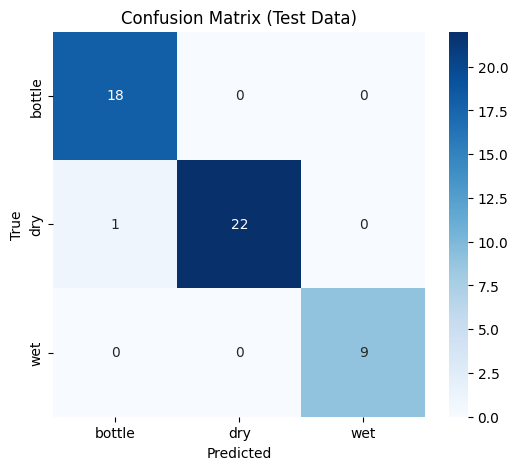

In [35]:
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# بارگذاری مدل YOLO
model = YOLO(r"C:\Users\HP\Desktop\best.pt")

# اجرای پیش‌بینی روی پوشه تست
results = model.predict(source=r"C:\Users\HP\Desktop\YOLO_TEST\images", save=False)

y_true = []
y_pred = []

# خواندن لیبل‌های واقعی و مقایسه با پیش‌بینی‌ها
for r in results:
    img_path = r.path
    label_path = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                cls_true = int(line.split()[0])   # کلاس واقعی (0=bottle, 1=dry, 2=wet)
                if len(r.boxes) > 0:
                    cls_pred = int(r.boxes.cls[0].item())  # کلاس پیش‌بینی‌شده
                else:
                    continue  # اگر هیچ پیش‌بینی نبود، رد می‌کنیم
                y_true.append(cls_true)
                y_pred.append(cls_pred)

# تعریف کلاس‌ها
labels = [0, 1, 2]
target_names = ["bottle", "dry", "wet"]

# گزارش کامل
print(classification_report(y_true, y_pred, labels=labels, target_names=target_names))

# ماتریس درهم‌ریختگی
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Data)")
plt.show()


ترکیب دو مدل


image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\cardboard212.jpg: 480x640 1 dry, 137.2ms
Speed: 7.1ms preprocess, 137.2ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\paper17.jpg: 480x640 1 dry, 110.2ms
Speed: 2.3ms preprocess, 110.2ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\paper60.jpg: 480x640 1 dry, 121.1ms
Speed: 2.6ms preprocess, 121.1ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\glass95.jpg: 480x640 1 bottle, 112.8ms
Speed: 1.8ms preprocess, 112.8ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\glass17.jpg: 480x640 1 bottle, 123.7ms
Speed: 3.1ms preprocess, 123.7ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


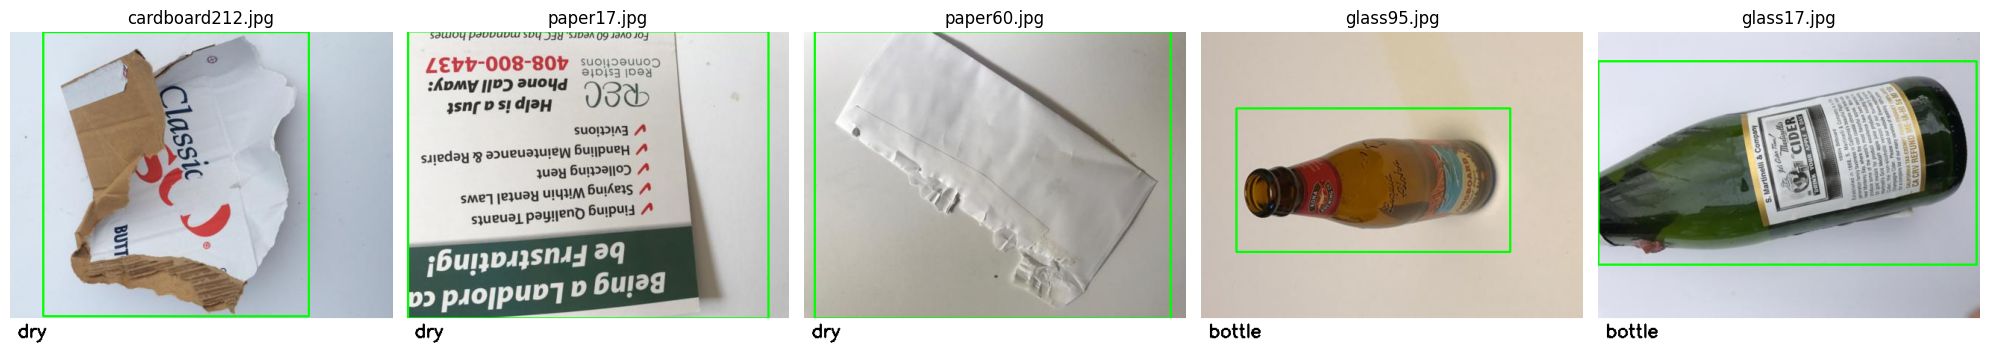


image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\biological580.jpg: 640x640 1 wet, 205.5ms
Speed: 6.2ms preprocess, 205.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\biological587.jpg: 448x640 3 wets, 107.8ms
Speed: 1.9ms preprocess, 107.8ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\biological74.jpg: 640x640 1 wet, 148.6ms
Speed: 3.7ms preprocess, 148.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\biological797.jpg: 640x640 1 wet, 158.1ms
Speed: 5.8ms preprocess, 158.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\biological964.jpg: 480x640 1 wet, 122.0ms
Speed: 1.9ms preprocess, 122.0ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\cardboard1.j

In [ ]:
import cv2
import os, random
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# 1. بارگذاری YOLO

yolo_model = YOLO(r"C:\Users\HP\Desktop\best.pt")

main_classes = ["bottle", "dry", "wet"]


# 2. مسیر تست

test_dir = r"C:\Users\HP\Desktop\YOLO_TEST\images"
all_images = os.listdir(test_dir)

# 3. نمایش 5 تصویر نمونه

sample_images = random.sample(all_images, 5)

plt.figure(figsize=(20,5))
for i, img_file in enumerate(sample_images):
    img_path = os.path.join(test_dir, img_file)
    results = yolo_model.predict(source=img_path, save=False)

    img = cv2.imread(img_path)
    final_texts = []

    for r in results:
        for box in r.boxes:
            cls_pred = int(box.cls.item())
            label_pred = main_classes[cls_pred]
            final_texts.append(label_pred)

            # رسم باندری‌باکس
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

    # اضافه کردن نوار سفید پایین تصویر
    bar_height = 40
    bar = 255 * np.ones((bar_height, img.shape[1], 3), dtype=np.uint8)
    img_with_bar = np.vstack([img, bar])

    text = " | ".join(final_texts)
    cv2.putText(img_with_bar, text, (10, img.shape[0] + 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,0), 2)

    plt.subplot(1, 5, i+1)
    plt.imshow(cv2.cvtColor(img_with_bar, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(img_file)

plt.tight_layout()
plt.show()


ارزیابی کلاس های اصلی


image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\biological580.jpg: 640x640 1 wet, 402.2ms
Speed: 12.0ms preprocess, 402.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\biological587.jpg: 448x640 3 wets, 135.6ms
Speed: 3.4ms preprocess, 135.6ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\biological74.jpg: 640x640 1 wet, 179.8ms
Speed: 4.8ms preprocess, 179.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\biological797.jpg: 640x640 1 wet, 188.2ms
Speed: 4.0ms preprocess, 188.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\biological964.jpg: 480x640 1 wet, 154.7ms
Speed: 2.3ms preprocess, 154.7ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\YOLO_TEST\images\cardboard1.

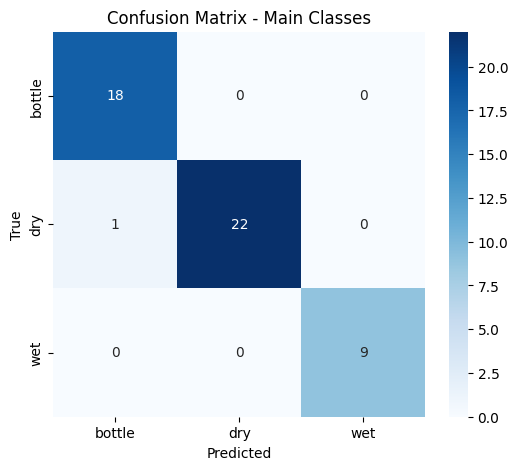

In [ ]:
# 4. ارزیابی روی کل دیتای تست
y_true_main, y_pred_main = [], []

for img_file in all_images:
    img_path = os.path.join(test_dir, img_file)
    results = yolo_model.predict(source=img_path, save=False)

    # لیبل واقعی
    label_path = img_path.replace("images","labels").rsplit(".",1)[0] + ".txt"
    true_labels = []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                cls_true = int(line.split()[0])
                true_labels.append(cls_true)

    # پیش‌بینی YOLO
    pred_labels = []
    for r in results:
        for box in r.boxes:
            cls_pred = int(box.cls.item())
            pred_labels.append(cls_pred)

    # هماهنگ کردن طول‌ها
    min_len = min(len(true_labels), len(pred_labels))
    y_true_main.extend(true_labels[:min_len])
    y_pred_main.extend(pred_labels[:min_len])


# 5. گزارش ارزیابی

print("Main Classes Evaluation (bottle/dry/wet)")
print(classification_report(y_true_main, y_pred_main,
                            target_names=["bottle","dry","wet"]))

cm_main = confusion_matrix(y_true_main, y_pred_main, labels=[0,1,2])
plt.figure(figsize=(6,5))
sns.heatmap(cm_main, annot=True, fmt="d", cmap="Blues",
            xticklabels=["bottle","dry","wet"],
            yticklabels=["bottle","dry","wet"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Main Classes")
plt.show()
